### Asian Hornet

In [ ]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from lightgbm import LGBMClassifier
from scipy.spatial import cKDTree


In [2]:
df = pd.read_csv('Data/Vespa velutina.csv')
df.head(10)

C:\Users\sidne\AppData\Local\Temp\ipykernel_7372\915384658.py:1: DtypeWarning: Columns (0: Vespa velutina) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Data/Vespa velutina.csv')


,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Vespa velutina
0,50.75,5.65,2010-01-01,0.0,0,0
1,50.75,5.65,2010-01-02,26.0,0,0
2,50.75,5.65,2010-01-03,3.0,0,0
3,50.75,5.65,2010-01-04,0.0,0,0
4,50.75,5.65,2010-01-05,0.0,0,0
5,50.75,5.65,2010-01-06,1.0,0,0
6,50.75,5.65,2010-01-07,0.0,0,0
7,50.75,5.65,2010-01-08,1.0,0,0
8,50.75,5.65,2010-01-09,0.0,0,0
9,50.75,5.65,2010-01-10,0.0,0,0


In [3]:
df2 = pd.read_csv('Data/habitats_cbs_2022.csv')
df2.head(10)

,decimalLongitude,decimalLatitude,agricultural,built,coast,forest,other,sand/heather,water,wetland,main_habitat
0,5.65,50.75,1.7747,0.0568,0.0,0.0616,0.0582,0.0000,0.4688,0.0,agricultural
1,5.70,50.75,9.9751,2.6012,0.0,0.9364,1.5790,0.0000,0.1626,0.0,agricultural
2,5.75,50.75,7.8028,0.8299,0.0,0.6983,0.4834,0.0000,0.0018,0.0,agricultural
3,5.80,50.75,13.2636,1.1357,0.0,0.8595,0.6516,0.0000,0.0045,0.0,agricultural
4,5.85,50.75,9.3689,0.5808,0.0,4.0774,0.8342,0.0252,0.0121,0.0,agricultural
5,5.90,50.75,12.6719,1.1557,0.0,2.7182,0.9720,0.0020,0.0208,0.0,agricultural
6,5.95,50.75,9.5586,1.0596,0.0,4.0747,0.7072,0.0076,0.0245,0.0,agricultural
7,6.00,50.75,1.7444,1.5170,0.0,0.5896,0.6602,0.0000,0.0108,0.0,agricultural
8,5.60,50.80,0.1024,0.5286,0.0,0.0000,0.2845,0.0000,0.0002,0.0,built
9,5.65,50.80,4.1292,4.5244,0.0,1.3542,2.3728,0.0000,1.4266,0.0,built


---

## 1. Business Understanding

#### **Situation Description**

The Vespa Velutina otherwise known as the Asian Hornet is an invasive species of insect present in the Netherlands. The Data Science Research Group tracks appearances of multiple plants and animals, including the Vespa, through the reports of various volunteers. The research group wants a way to predict the appearances of future Vespa. 

#### **Business Objective(s)**

The goal of this notebook is to create a model that can accurately predict whether or not a Vespa will be located within an area on a specific date.
This model is meant to give insight into the behavior of the Vespa, which can be used for the potential combating of the invasive Vespa.

#### **Data Mining Goal(s)**

The goal is to create a new binary column `Vespa_spotted` that indicated whether a Vespa has been spotted on a specific place and date.

While we are creating a new column, this is a supervised learning modeling task. We are trying to make predictions using existing and labeled data columns. We already know what we are trying to make, a prediction model to show if a Vespa will be spotted at a specific place and time.

This is a classification task. While we are using the `Vespa Velutina` column which shows the amount of Vespa spotted using numbers to create our model, the ultimate goal is simply to predict if there will be sighting, not how many will be sighted.

#### **Success Criteria**

With the large amount of zero values within our data set, simply predicting no Vespa will be spotted would result in a high score with most metrics. This would not be a useful result however, and the accurate prediction of when Vespa will be spotted is more valuable, therefore, to measure the success of our model we will mostly look towards the recall score.

**Recall:** 80%

In case the above percentage proves to be able to be achieved too easily, the possibility to pick a more strict goal will remain.

---

## 2. Data Understanding

**Data exploration**

In [4]:

df1 = df.iloc[:-30]

print(df)
df['eventDate'] = pd.to_datetime(df['eventDate'])
df['year'] = df['eventDate'].dt.year
df['month'] = df['eventDate'].dt.month

print(f"Dataset vorm: {df.shape}")
print(f"\nEerste rijen:")
print(df.head())
print(f"\nGegevenstypen:")
print(df.dtypes)
print(f"\nBasisstatistieken:")
print(df.describe())

          decimalLatitude  decimalLongitude   eventDate  total_observations  \
0                   50.75              5.65  2010-01-01                 0.0   
1                   50.75              5.65  2010-01-02                26.0   
2                   50.75              5.65  2010-01-03                 3.0   
3                   50.75              5.65  2010-01-04                 0.0   
4                   50.75              5.65  2010-01-05                 0.0   
...                   ...               ...         ...                 ...   
12558781             4.30             53.10  2026-01-26                90.0   
12558782             4.25             53.05  2026-01-27                50.0   
12558783             4.20             52.95  2026-01-28             99999.0   
12558784             4.15             52.90  2026-01-29             99999.0   
12558785             4.10             52.80  2026-01-30                80.0   

          speciesgroup_observations Vespa velutina 

**Visualizations and patterns**

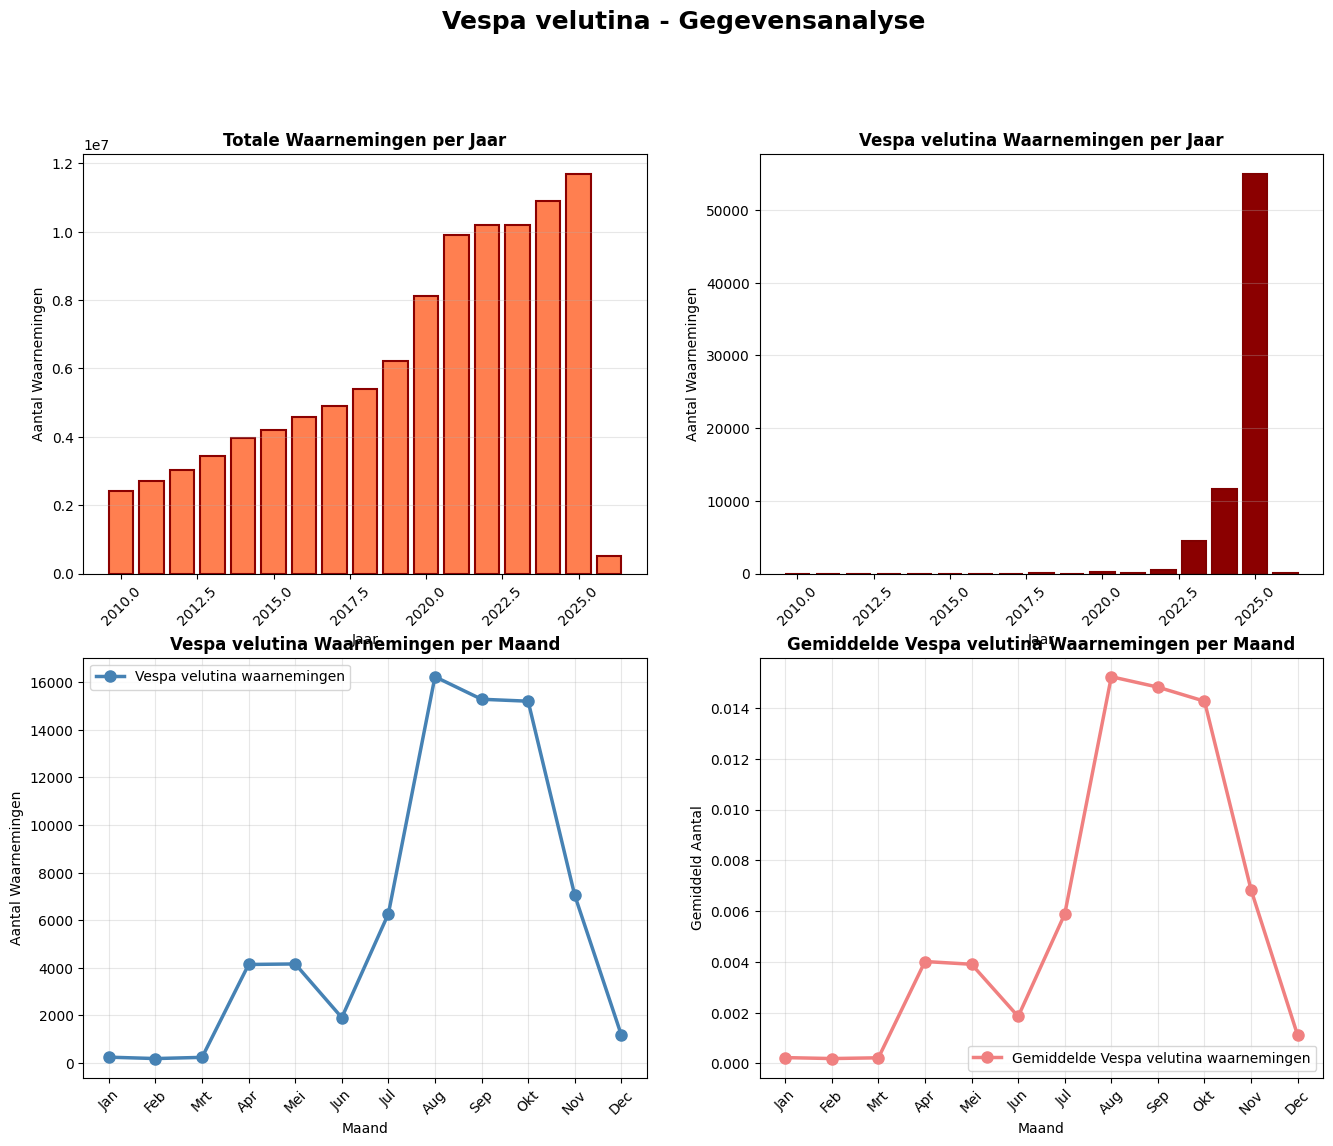

In [5]:


# Maak een figure met meerdere subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Vespa velutina - Gegevensanalyse', fontsize=18, fontweight='bold', y=1.00)

# 1. Totale waarnemingen per jaar
yearly_data = df.groupby('year')['total_observations'].sum()
axes[0, 0].bar(yearly_data.index, yearly_data.values, color='coral', edgecolor='darkred', linewidth=1.5)
axes[0, 0].set_title('Totale Waarnemingen per Jaar', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Jaar')
axes[0, 0].set_ylabel('Aantal Waarnemingen')
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Vespa velutina waarnemingen per jaar
vespa_yearly = pd.to_numeric(df['Vespa velutina'], errors='coerce').fillna(0).groupby(df['year']).sum()
axes[0, 1].bar(vespa_yearly.index, vespa_yearly.values, color='darkred', edgecolor='maroon', linewidth=1.5)
axes[0, 1].set_title('Vespa velutina Waarnemingen per Jaar', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('Jaar')
axes[0, 1].set_ylabel('Aantal Waarnemingen')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Vespa velutina waarnemingen per maand
vespa_monthly = pd.to_numeric(df['Vespa velutina'], errors='coerce').fillna(0).groupby(df['month']).sum()
month_names = ['Jan', 'Feb', 'Mrt', 'Apr', 'Mei', 'Jun', 'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dec']
axes[1, 0].plot(vespa_monthly.index, vespa_monthly.values, marker='o', linewidth=2.5, markersize=8, 
                color='steelblue', label='Vespa velutina waarnemingen')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(month_names, rotation=45)
axes[1, 0].set_title('Vespa velutina Waarnemingen per Maand', fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Maand')
axes[1, 0].set_ylabel('Aantal Waarnemingen')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

# 4. gemiddelde Vespa velutina waarnemingen per maand 
vespa_monthly_avg = pd.to_numeric(df['Vespa velutina'], errors='coerce').fillna(0).groupby(df['month']).mean()
axes[1, 1].plot(vespa_monthly_avg.index, vespa_monthly_avg.values, marker='o', linewidth=2.5, markersize=8,
                color='lightcoral', label='Gemiddelde Vespa velutina waarnemingen')
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].set_xticklabels(month_names, rotation=45)
axes[1, 1].set_title('Gemiddelde Vespa velutina Waarnemingen per Maand', fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Maand')
axes[1, 1].set_ylabel('Gemiddeld Aantal')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

## Data Insights and Data Quality

### Data Insights

### Data Quality Issues

---

## 3. Data Preparation

**Cleaning and preprocessing**

our customer had already done some data cleaning so our data set is reletively clean.

the biggest problem in the data set is the mix between strings and integers, these all have to be converted to integers.

there are also some data anomoly's such as 9999 values that make no sense and repeated 1001 value's that also seem incorrect as well.

## Data Cleaning and Preprocessing

In [6]:
df['Vespa velutina'].value_counts()

Vespa velutina
0          12404637
0            106914
1             33020
2              8791
3              2980
4              1239
5               540
6               274
7               151
8                86
9                34
10               30
11               16
12               11
13               10
14                6
4                 5
15                4
1                 4
3                 4
19                3
16                3
5                 3
unknown           3
8                 3
2                 3
20                2
7                 2
9                 2
32                1
22                1
17                1
-1                1
6                 1
10                1
Name: count, dtype: int64

To more easily fix all the data I first normalized all the incorrect strings to be the same format

In [7]:
# normalize the column and change all to numbers
df["Vespa velutina"] = (
    df["Vespa velutina"]
    .astype(str)
    .str.strip()
    .str.lower()
)

than I changed all the incorrect strings to NA

In [8]:
# remove rows with unknown-like values
df = df[
    ~df["Vespa velutina"].str.contains(
        r"^(unknown|\?|na|n/a|nan)?$",
        na=True
    )
]

C:\Users\sidne\AppData\Local\Temp\ipykernel_7372\2672287213.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~df["Vespa velutina"].str.contains(


all the numbers in string form are changed to integers

In [9]:
# changes all strings to int
def convert_mixed(val):
    try:
        return int(val)
    except:
        return val

df["Vespa velutina clean"] = df["Vespa velutina"].apply(convert_mixed)

# encode only the strings
strings = df["Vespa velutina"].astype(str)
df["Vespa velutina"] = pd.factorize(strings)[0]

all the imposible numbers and NA's are removed leaving us with a clean dataset

In [10]:
def RM_incorrect_num(val):
  if val == 1011:
    return pd.NA
  else:
    return val
  
df["speciesgroup_observations"] = df["speciesgroup_observations"].apply(RM_incorrect_num)

df = df.dropna(subset=["speciesgroup_observations"])


the second data set was a lot cleaner, all we did was remove all rows with "dirt" as main type sinds we couldn't use these

In [11]:
df2 = df2[
    ~df2["main_habitat"].str.contains(
        r"^(dirt)?$",
        na=True
    )
]

df2 = df2.dropna(subset=["main_habitat"])


C:\Users\sidne\AppData\Local\Temp\ipykernel_7372\3956329035.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~df2["main_habitat"].str.contains(


I merged the data sets with a left merge to preserve all the data from our species and add the habitat data to the respective rows

In [12]:
# merge op latitude + longitude
df_merged = df.merge(
    df2,
    on=["decimalLatitude", "decimalLongitude"],
    how="left"   # behoud alle rijen
)

print(df_merged.head())

   decimalLatitude  decimalLongitude  eventDate  total_observations  \
0            50.75              5.65 2010-01-01                 0.0   
1            50.75              5.65 2010-01-02                26.0   
2            50.75              5.65 2010-01-03                 3.0   
3            50.75              5.65 2010-01-04                 0.0   
4            50.75              5.65 2010-01-05                 0.0   

  speciesgroup_observations  Vespa velutina  year  month  \
0                         0               0  2010      1   
1                         0               0  2010      1   
2                         0               0  2010      1   
3                         0               0  2010      1   
4                         0               0  2010      1   

   Vespa velutina clean  agricultural   built  coast  forest   other  \
0                     0        1.7747  0.0568    0.0  0.0616  0.0582   
1                     0        1.7747  0.0568    0.0  0.0616  0.0582

create a bunch of csv's to more easily acces data without having to rerun all commands

In [13]:
#create a csv to save proceccing time not having to rerun all previous commands
df.to_csv("Data/Vespa velutina Fixed.csv")

In [14]:
#create a csv to save proceccing time not having to rerun all previous commands
df2.to_csv("Data/habitats_fixed.csv")

In [15]:
#create a csv to save proceccing time not having to rerun all previous commands
df_merged.to_csv("Data/Vespa merged.csv")


## 4. modeling

**gradient boosting**

In [ ]:
df = pd.read_csv("Data/Vespa merged.csv")

# Target fix (binary)

df["Vespa velutina"] = (df["Vespa velutina"] > 0).astype(int)

# Date features

df["eventDate"] = pd.to_datetime(df["eventDate"])

df["year"] = df["eventDate"].dt.year
df["month"] = df["eventDate"].dt.month
df["dayofyear"] = df["eventDate"].dt.dayofyear


# Spatial features 
# grid (≈ 1 km-ish)
df["grid_x"] = (df["decimalLongitude"] * 10).astype(int)
df["grid_y"] = (df["decimalLatitude"] * 10).astype(int)

# density per grid cell
grid_counts = df.groupby(["grid_x", "grid_y"]).size().reset_index(name="grid_density")
df = df.merge(grid_counts, on=["grid_x", "grid_y"], how="left")

pos = df[df["Vespa velutina"] == 1][["decimalLatitude", "decimalLongitude"]].values

# fallback als weinig positives
if len(pos) > 10:
    tree = cKDTree(pos)
    coords = df[["decimalLatitude", "decimalLongitude"]].values
    dist, _ = tree.query(coords, k=1)
    df["dist_to_nearest_sighting"] = dist
else:
    df["dist_to_nearest_sighting"] = 0


# Features
features = [
    "decimalLatitude",
    "decimalLongitude",
    "grid_x",
    "grid_y",
    "grid_density",
    "dist_to_nearest_sighting",
    "total_observations",
    "speciesgroup_observations",
    "year",
    "month",
    "dayofyear"
]

X = df[features]
y = df["Vespa velutina"]


# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = neg / pos


# Model
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)


# Train
model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob > 0.5).astype(int)


# Evaluation
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

[LightGBM] [Info] Number of positive: 37764, number of negative: 10009240
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.240309 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 841
[LightGBM] [Info] Number of data points in the train set: 10047004, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.003759 -> initscore=-5.579908
[LightGBM] [Info] Start training from score -5.579908
ROC-AUC: 0.9877682365834642
PR-AUC: 0.2586573974935738
              precision    recall  f1-score   support

           0       1.00      0.95      0.97   2502311
           1       0.07      0.96      0.12      9441

    accuracy                           0.95   2511752
   macro avg       0.53      0.96      0.55   2511752
weighted avg       1.00      0.95      0.97   2511752

